In [1]:
#bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi']=400
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('Chapter_1_cleaned_data.csv')

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,EDUCATION_CAT,graduate school,high school,none,others,university
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,1,university,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,1000,0,2000,1,university,0,0,0,0,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,1000,1000,5000,0,university,0,0,0,0,1
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,1100,1069,1000,0,university,0,0,0,0,1
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,9000,689,679,0,university,0,0,0,0,1


In [4]:
#Criando dados sintéticos
np.random.seed(1)
x = np.random.uniform(low=0.0, high=10.0, size=(1000,))

slope = 0.25
intercept = -1.25
noise = np.random.normal(loc=0.0, scale=1.0, size=(1000,))
y = slope * x + intercept + noise 


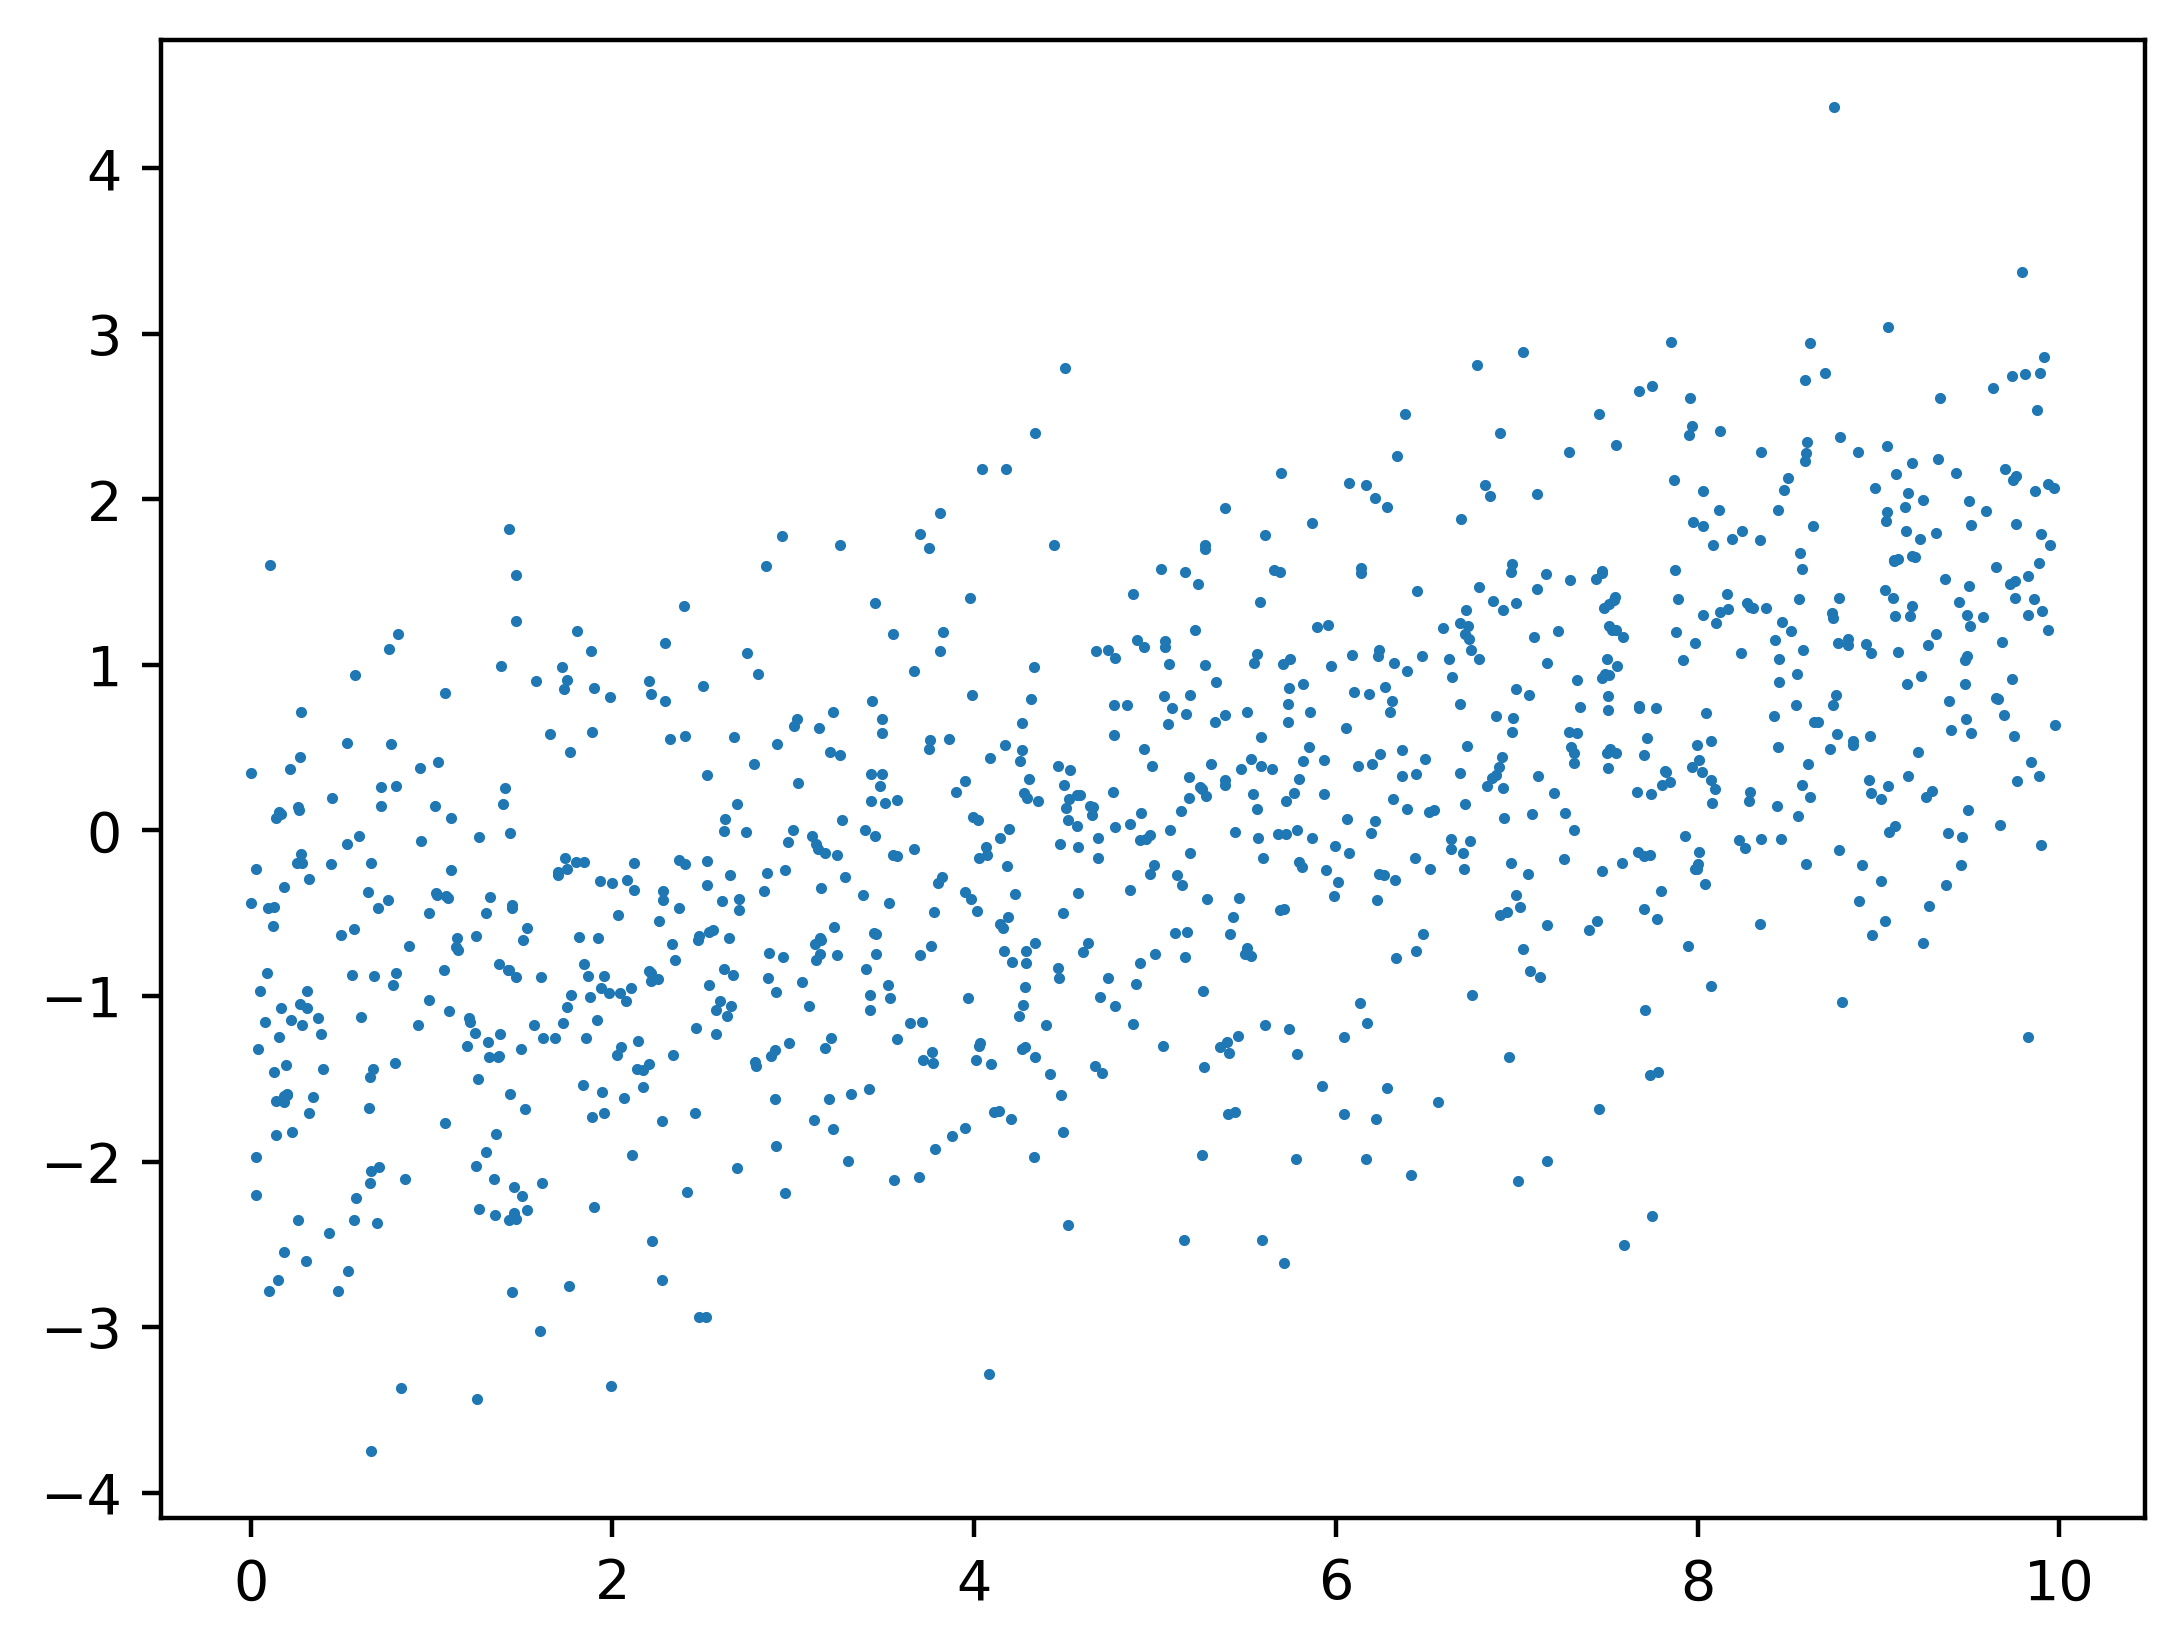

In [5]:

plt.scatter(x,y, s=1);

In [6]:
#Treinamento do modelo
x.reshape(-1,1).shape

(1000, 1)

In [7]:
lr = LinearRegression()
lr.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'normalize': 'deprecated',
 'positive': False}

In [8]:
#Treinamento do modelo
lr.fit(x.reshape(-1,1),y)

LinearRegression()

In [9]:

lr.coef_,lr.intercept_

(array([0.25106337]), -1.2080021895763122)

In [10]:
#Fazendo as previsões
y_pred = lr.predict(x.reshape(-1,1))
y_pred[:10]

array([-0.16101268,  0.60046878, -1.20771504, -0.44895584, -0.8395519 ,
       -0.9761738 , -0.74037102, -0.34042577, -0.21186439,  0.14476928])

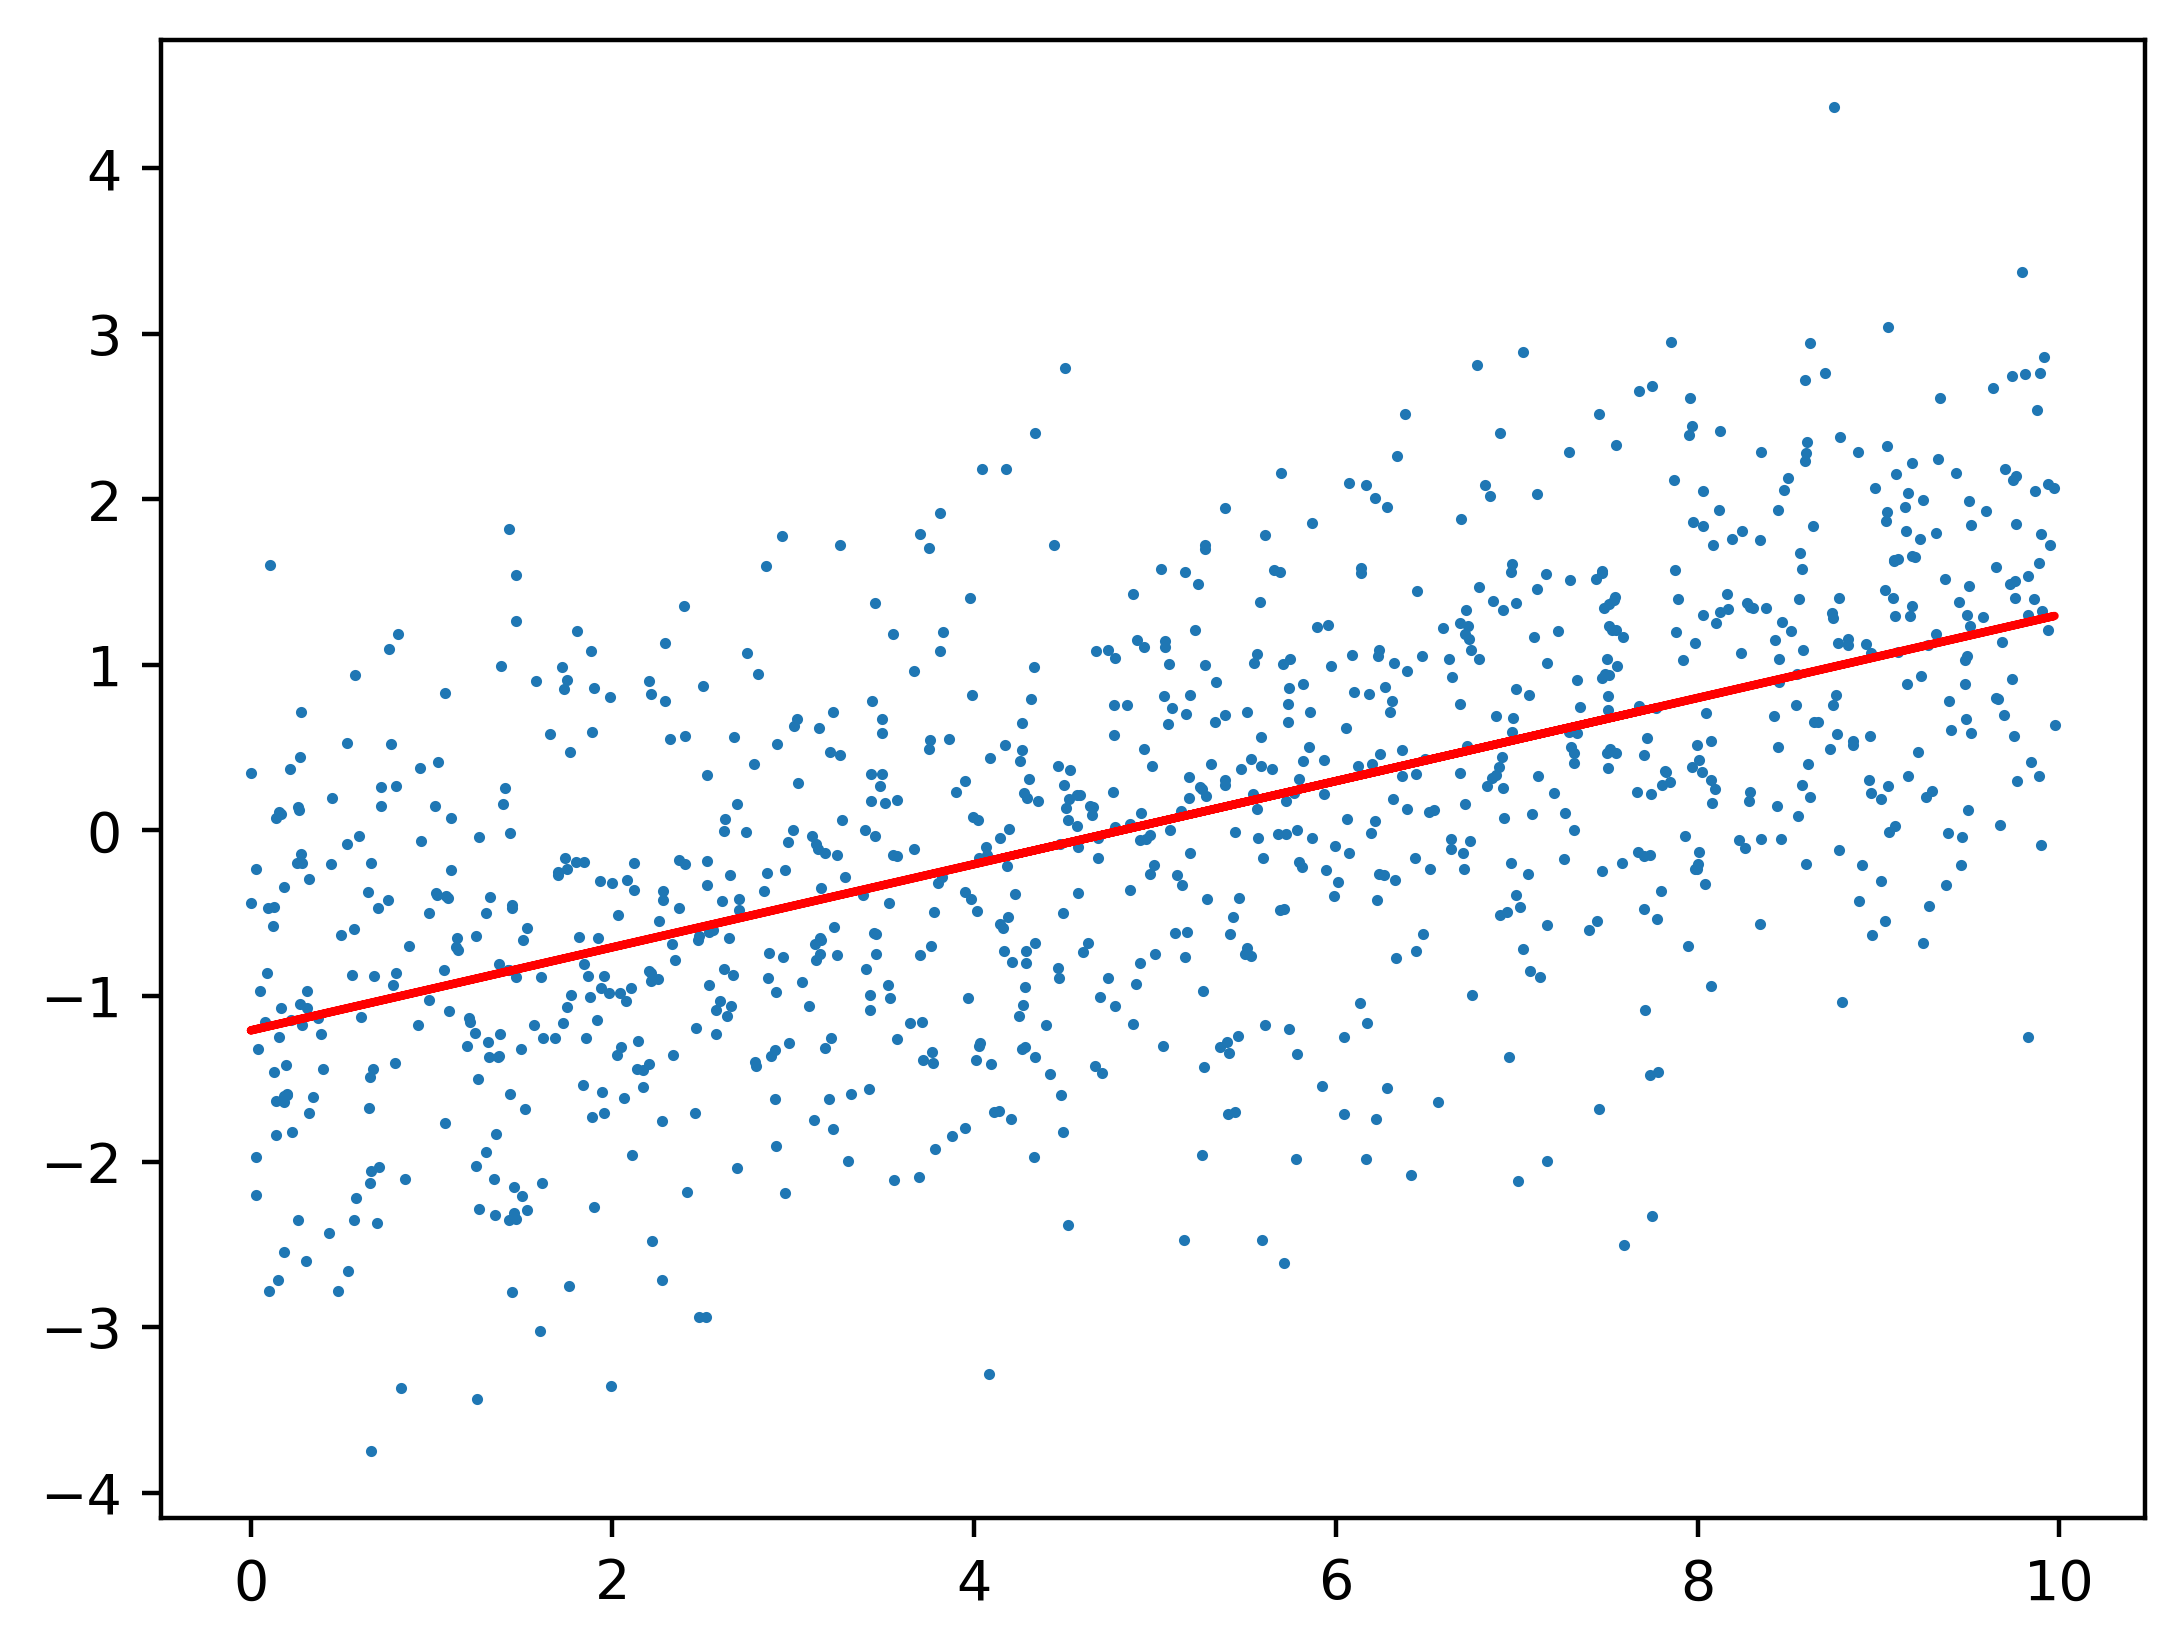

In [11]:
plt.scatter(x,y,s=1)
plt.plot(x,y_pred,'r')

In [12]:
#Dividindo dados em treino e teste 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    df['EDUCATION'].values.reshape(-1,1), df['default payment next month'].values, test_size=0.2, random_state=24)

In [13]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(21331, 1)
(5333, 1)
(21331,)
(5333,)


In [14]:
np.mean(y_train)

0.223102526838873

In [15]:
np.mean(y_test)

0.21657603600225014

In [16]:
#Acurácia da classificação
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

In [17]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [18]:
#Valor ou percentual da acurácia, a média de valores que resultaram em true no array de y_pred = y_test
acc = np.mean(y_pred == y_test)
#outra forma de apurar, acc = sum(y_pred == y_test) / len(y_pred)

In [19]:
acc

0.7834239639977498

In [20]:
#amostras positivas
p = sum(y_test)
p

1155

In [21]:
#verdadeiros positivos
tp = sum((y_test==1)&(y_pred==1))
tp

0

In [22]:
#taxa de verdadeiros positivos
TPR = tp/p
TPR

0.0

In [23]:
#falsos negativos
fn = sum((y_test==1)&(y_pred==0))
fn

1155

In [24]:
#taxa de falsos negativos
FNR = fn/p
FNR

1.0

In [25]:
#Colocando todos em uma célula só

TP1= sum((y_pred==1) & (y_test==1))
TN1= sum((y_pred==0) & (y_test==0))
FP1= sum((y_pred==1) & (y_test==0))
FN1= sum((y_pred==0) & (y_test==1))

TP1, TN1, FP1, FN1

(0, 4178, 0, 1155)

In [26]:
acuracia = (TP1+TN1)/(TP1+TN1+FP1+FN1)
acuracia

0.7834239639977498

In [27]:
lr.predict_proba(x_test)

array([[0.77460214, 0.22539786],
       [0.77460214, 0.22539786],
       [0.79040961, 0.20959039],
       ...,
       [0.79040961, 0.20959039],
       [0.79040961, 0.20959039],
       [0.79040961, 0.20959039]])

In [28]:
#a soma de todas as linhas são 1
np.sum(lr.predict_proba(x_test),1)

array([1., 1., 1., ..., 1., 1., 1.])

In [29]:
# para comprovar que todas as linhas são 01
np.unique(np.sum(lr.predict_proba(x_test),1))

array([1.])

In [30]:
np.sum(lr.predict_proba(x_test),1).shape

(5333,)

In [31]:
#verificando as probabilidade positivas
pos_proba=lr.predict_proba(x_test)[:,1]

Text(0, 0.5, 'Number of samples')

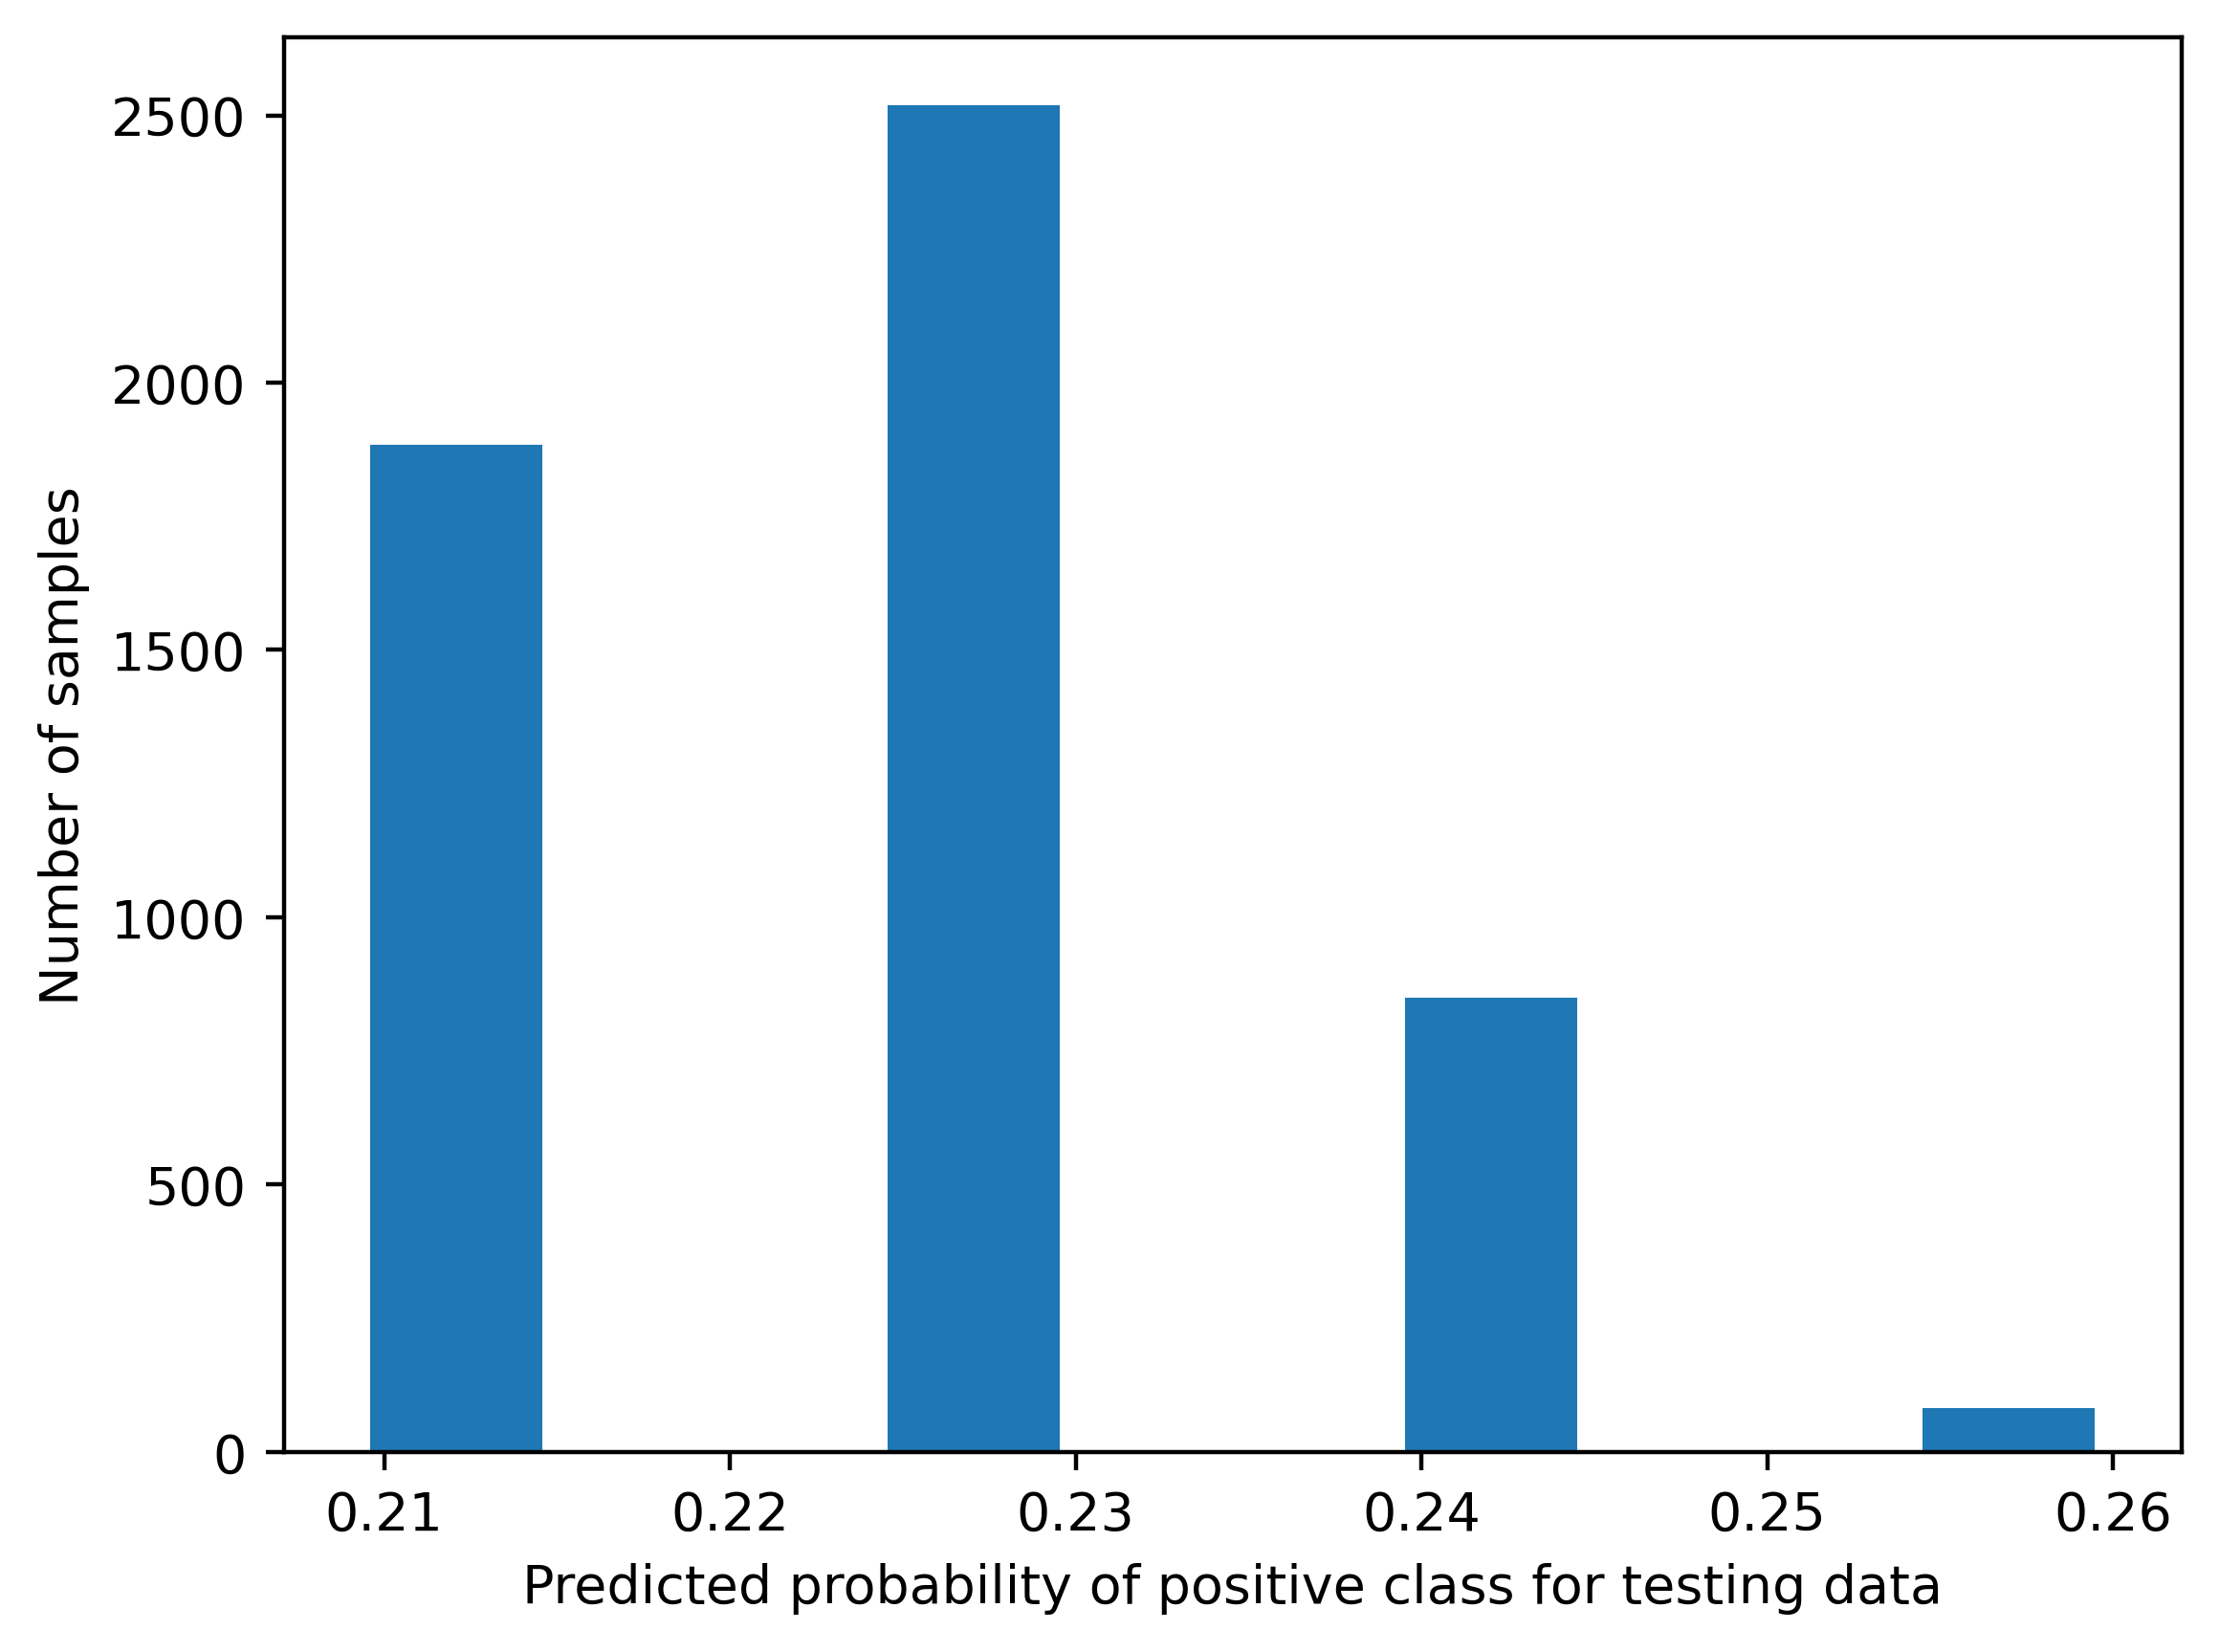

In [32]:
plt.hist(pos_proba)
plt.xlabel('Predicted probability of positive class for testing data')
plt.ylabel('Number of samples')

In [34]:
#Isolar as probabilidades pos/negativo

pos_sample_pos_proba = pos_proba[y_test==1]
neg_sample_pos_proba = pos_proba[y_test==0]

Text(0, 0.5, 'Number of samples')

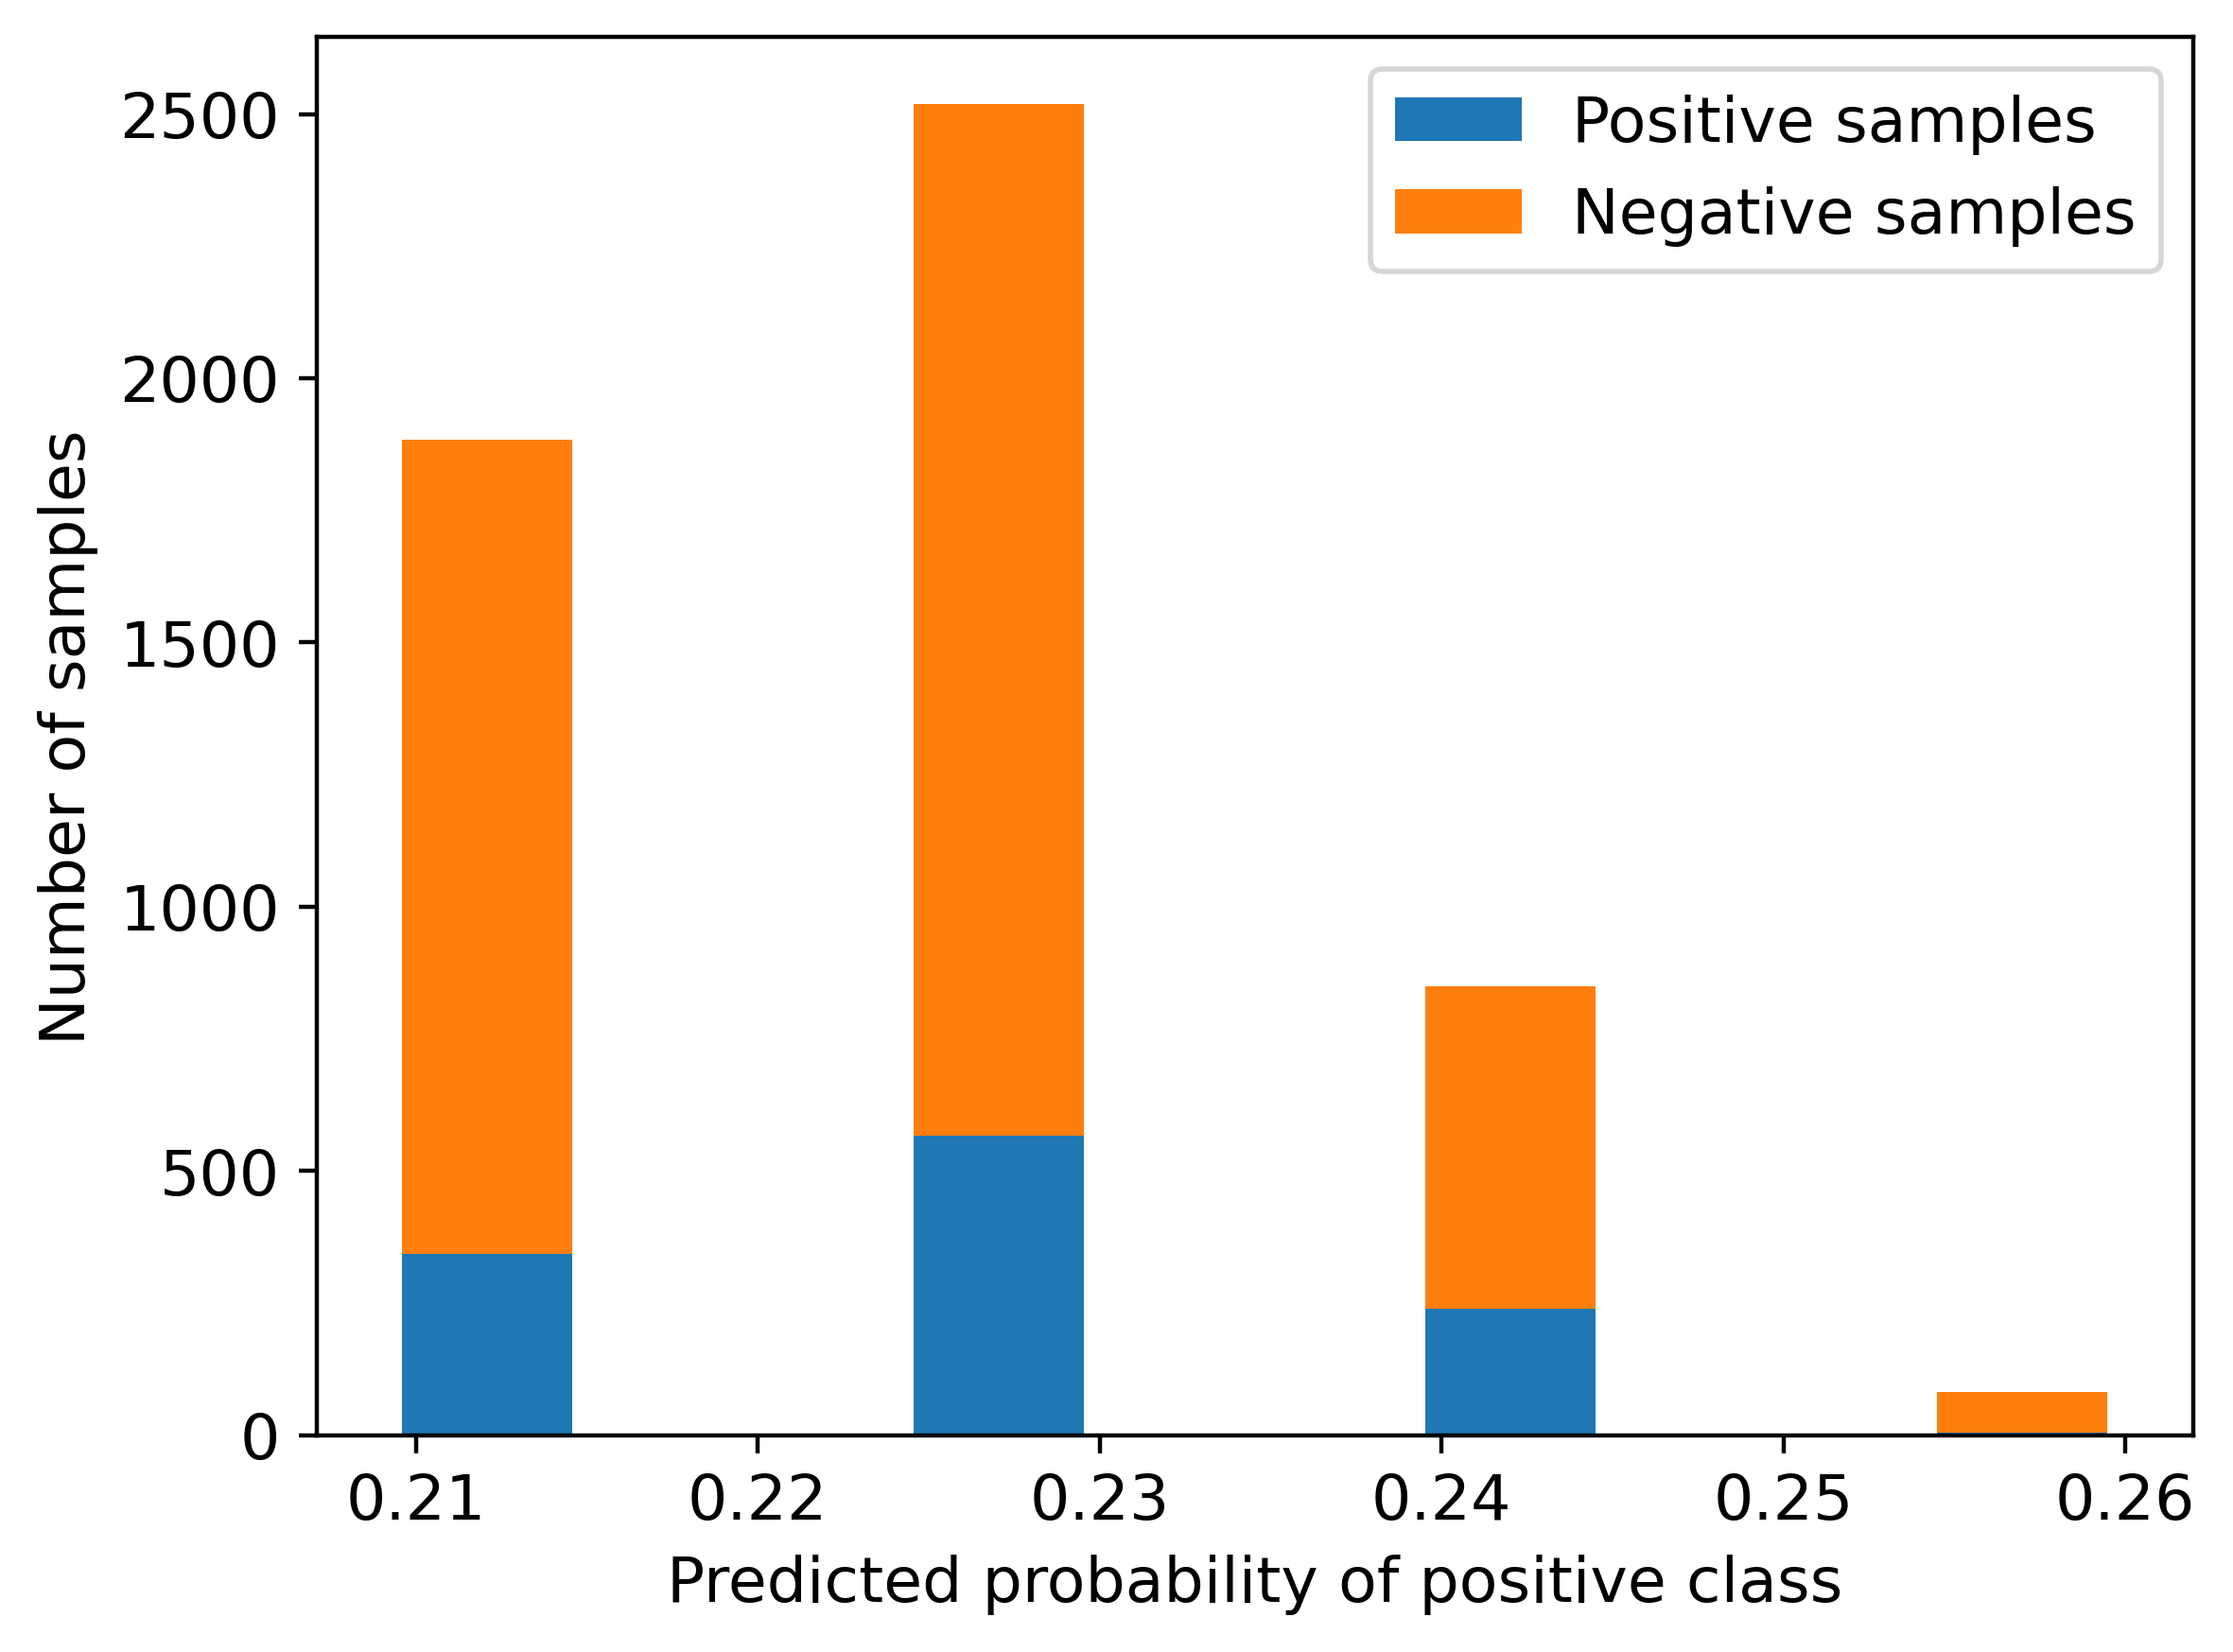

In [36]:
plt.hist([pos_sample_pos_proba,neg_sample_pos_proba],histtype='barstacked')
plt.legend(['Positive samples', 'Negative samples'])
plt.xlabel('Predicted probability of positive class')
plt.ylabel('Number of samples')

In [44]:
from sklearn import metrics

fpr,tpr,thresholds = metrics.roc_curve(y_test,pos_proba)

Text(0, 0.5, 'TPR')

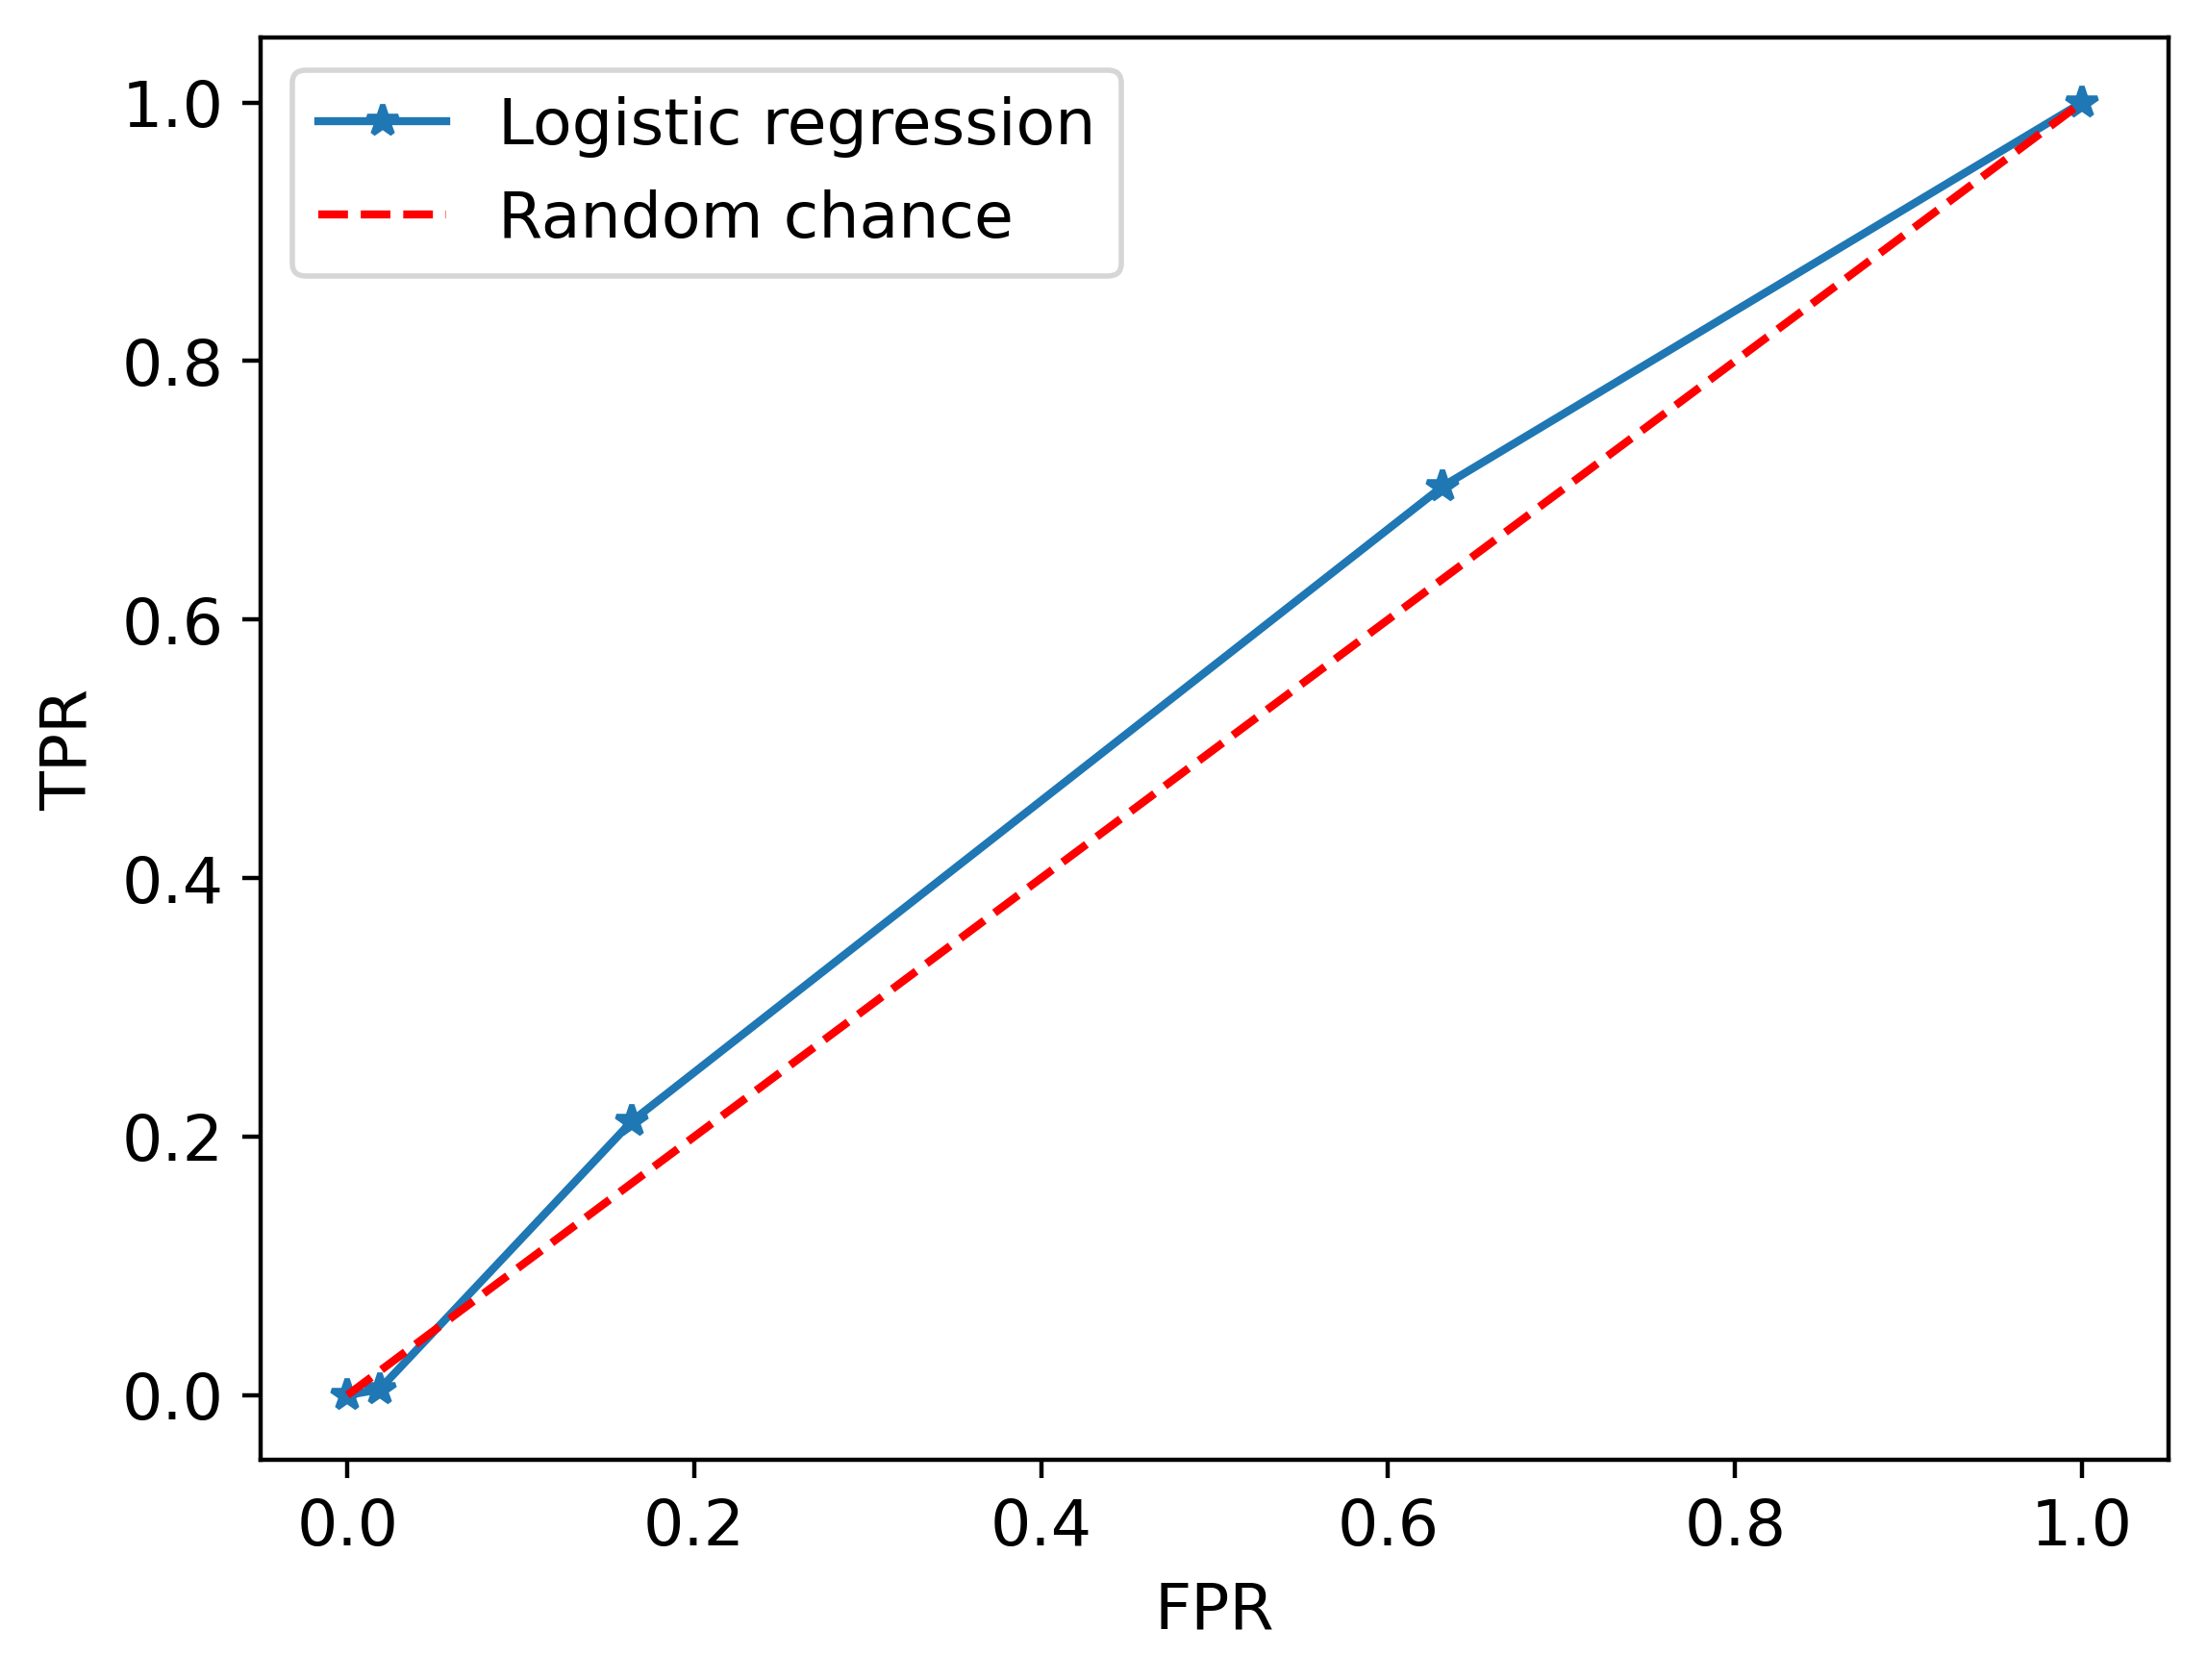

In [47]:
plt.plot(fpr,tpr,'*-')
plt.plot([0,1], [0,1],'r--')
plt.legend(['Logistic regression', 'Random chance'])
plt.xlabel('FPR')
plt.ylabel('TPR')


In [48]:
thresholds

array([1.25948347, 0.25948347, 0.24203246, 0.22539786, 0.20959039])

In [49]:
#área abaixo da curva (AUC)
metrics.roc_auc_score(y_test,pos_proba)

0.5434650477972642

In [58]:
#A precisão examina a proporção de verdadeiros positivos em relação à soma de verdadeiros e falsos positivos 

TP2= sum((y_pred==1) & (y_test==1))
TN2= sum((y_pred==0) & (y_test==0))
FP2= sum((y_pred==1) & (y_test==0))
FN2= sum((y_pred==0) & (y_test==1))

#p= TP2 / (TP2+FP2)